****Imports and Data Loading****

We load the Diabetes dataset directly from scikit-learn. By setting as_frame=True, it returns a clean Pandas DataFrame rather than raw NumPy arrays.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Inspect the first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


****Exploratory Data Analysis (EDA)****

Exploratory data analysis helps us understand data distributions, missing values, and linear correlations between features and the target variable (disease progression one year after baseline)

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Summary Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


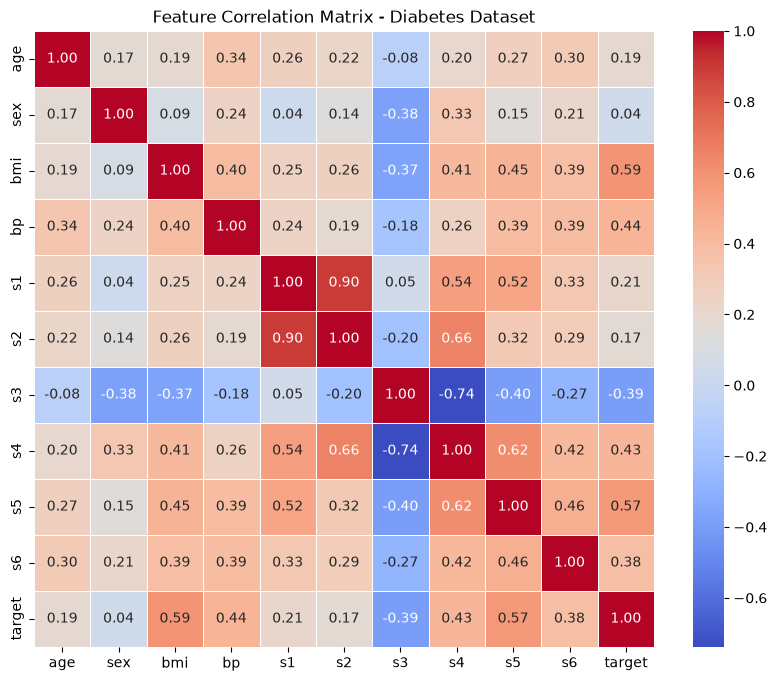

In [4]:
# Check dataset info and summary statistics
print(df.info())
print("\nSummary Statistics:")
display(df.describe())

# Visualize feature correlations using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix - Diabetes Dataset")
plt.show()

****Splitting the Dataset****

We separate our features (X) from our target (y) and split the data into training and testing partitions to evaluate generalization performance accurately

In [5]:
X = df.drop(columns=["target"])
y = df["target"]

# 80% training, 20% testing split with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (353, 10)
Testing set shape: (89, 10)


****Training the Linear Regression Model****

We initialize and fit the Ordinary Least Squares (OLS) Linear Regression model using our training data.

In [6]:
# Initialize and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


****Interpreting Regression Coefficients****

The model coefficients indicate how much the target variable changes for a one-unit change in a given feature, holding other features constant.

In [7]:
# Create a dataframe to view features alongside their learned coefficients
coef_df = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": lr_model.coef_}
).sort_values(by="Coefficient", ascending=False)

display(coef_df)
print(f"Intercept: {lr_model.intercept_:.2f}")

,Feature,Coefficient
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
6,s3,163.419983
9,s6,48.670657
0,age,37.904021
1,sex,-241.964362
4,s1,-931.488846


Intercept: 151.35


****Evaluating Predictions****

We compute standard regression evaluation metrics—Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$)

In [8]:
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Evaluation Metrics:")
print(f"-------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Evaluation Metrics:
-------------------
MAE  : 42.79
MSE  : 2900.19
RMSE : 53.85
R²   : 0.45


****Visualizing Model Performance****

Visualizations give immediate insight into how well predictions align with actual values and check whether errors are randomly distributed (via residuals).

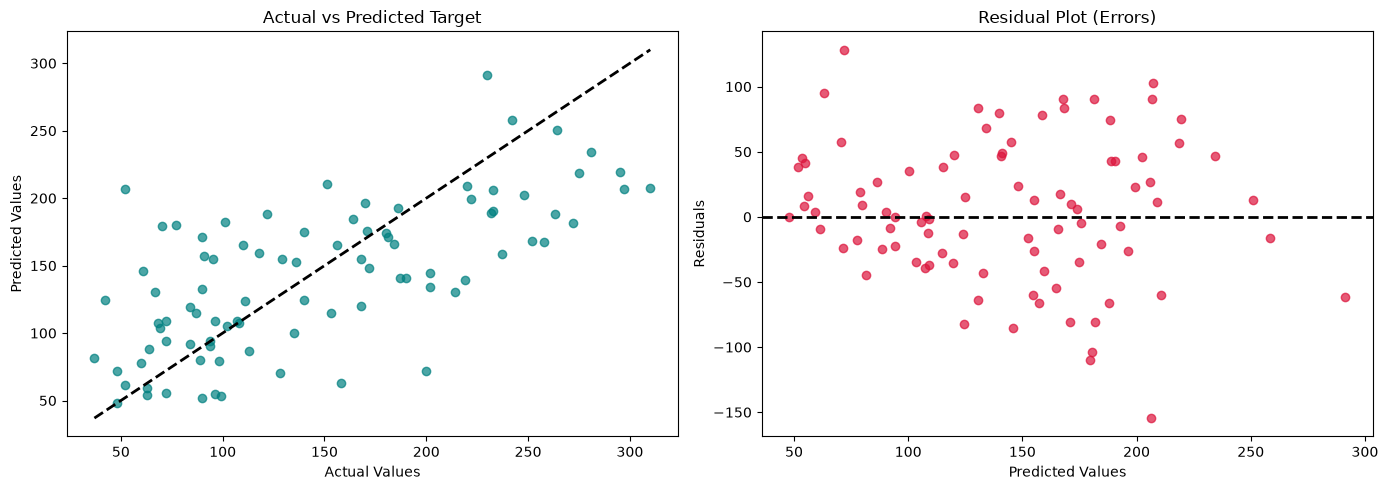

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted Scatter Plot
axes[0].scatter(y_test, y_pred, alpha=0.7, color="teal")
axes[0].plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2
)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Target")

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color="crimson")
axes[1].axhline(y=0, color="k", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot (Errors)")

plt.tight_layout()
plt.show()

****Making Predictions for Unseen Data & Assessment****

Demonstrating how to pass a mock unseen sample to the model, followed by a critical assessment.

In [10]:
# Simulate an unseen data point by taking the first row of X_test
unseen_sample = X_test.iloc[[0]]
predicted_progression = lr_model.predict(unseen_sample)

print(f"Unseen Sample Features:\n{unseen_sample}")
print(f"\nPredicted Disease Progression: {predicted_progression[0]:.2f}")
print(f"Actual Disease Progression: {y_test.iloc[0]}")

Unseen Sample Features:
          age       sex       bmi        bp        s1        s2        s3  \
287  0.045341 -0.044642 -0.006206 -0.015999  0.125019  0.125198  0.019187   

           s4        s5       s6  
287  0.034309  0.032432 -0.00522  

Predicted Disease Progression: 139.55
Actual Disease Progression: 219.0


***Critical Assessment Notes:***

**Strengths**: Linear regression is computationally efficient, highly interpretable due to explicit feature coefficients, and serves as a fast baseline model.

**Limitations**: It assumes a strictly linear relationship between features and the target. If underlying biological or clinical variables interact non-linearly, standard linear regression can suffer from high bias.